month
0    0.011326
1    0.009387
2    0.008746
3    0.009222
4    0.011371
5    0.011825
6    0.013405
7    0.014746
Name: fraud_bool, dtype: float64


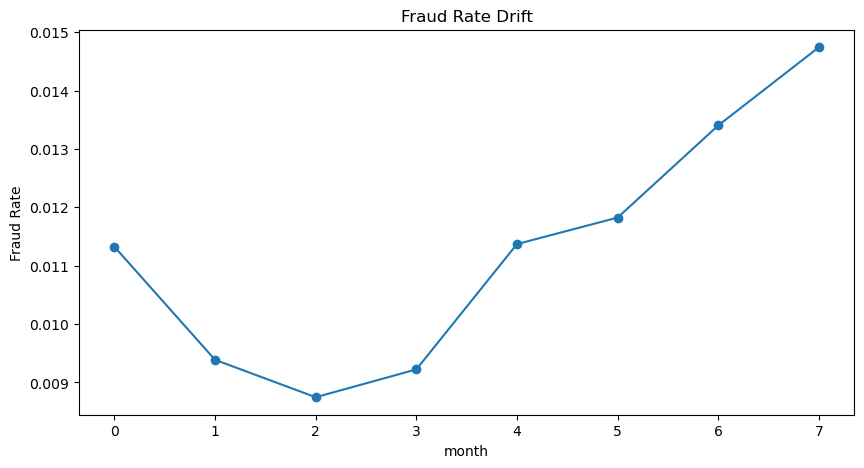

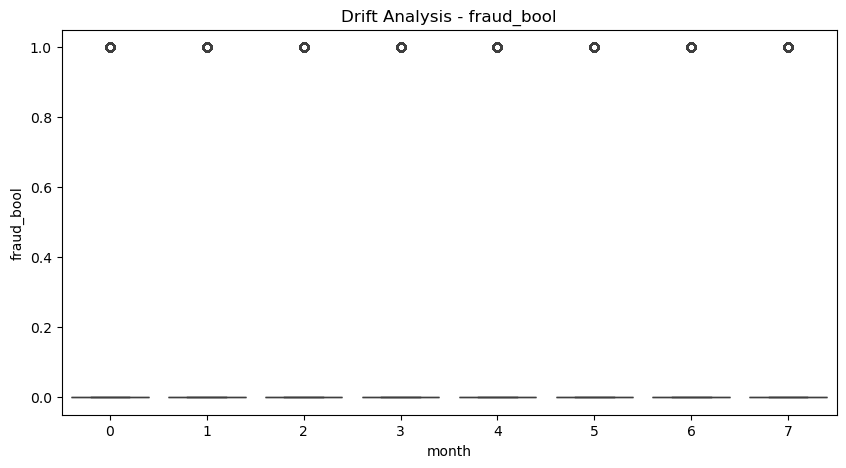

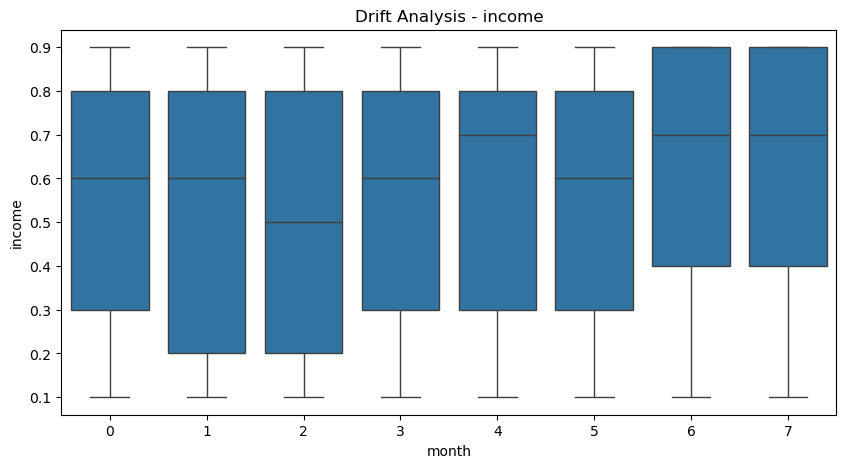

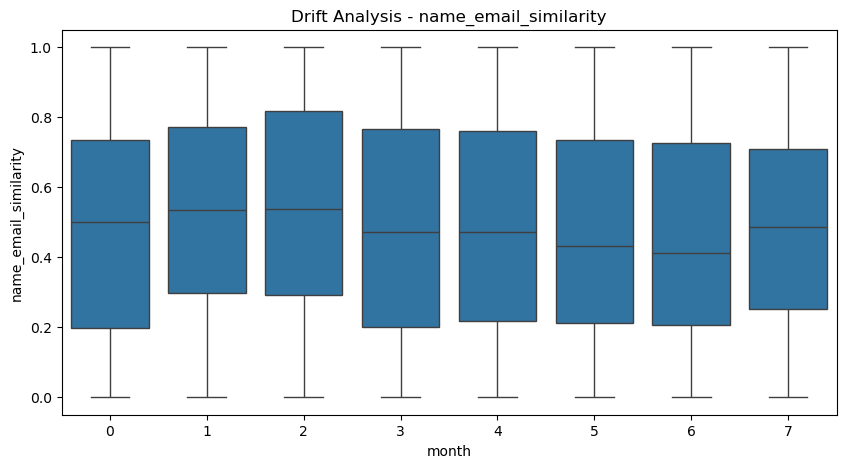

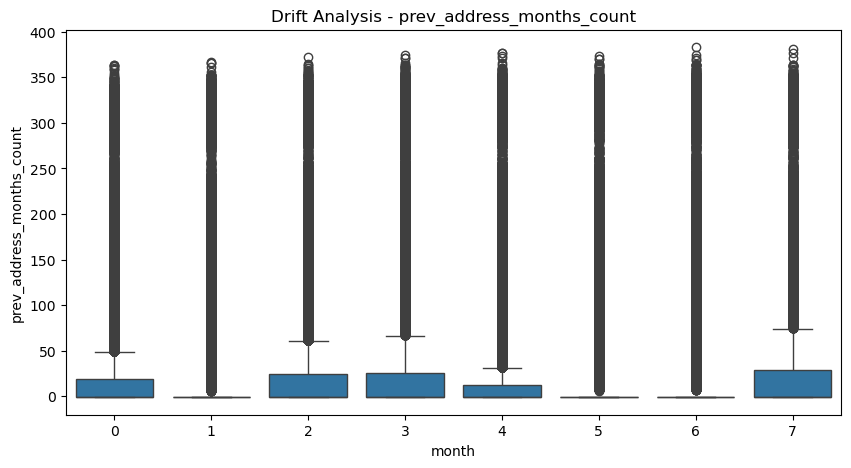

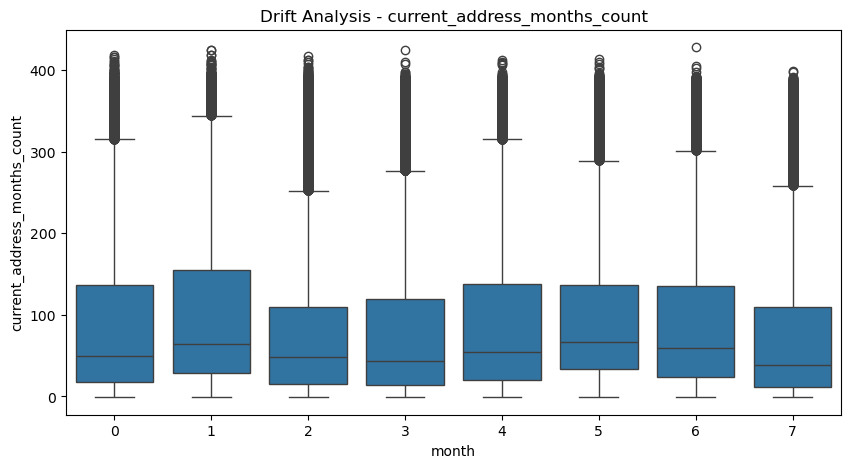

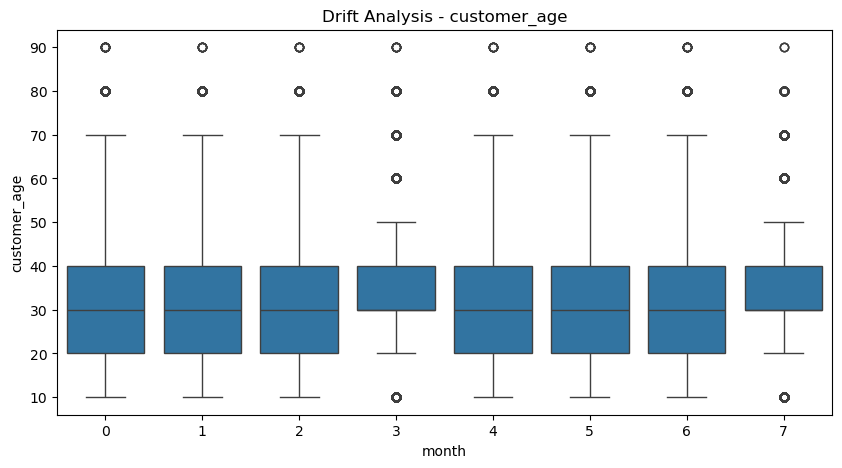

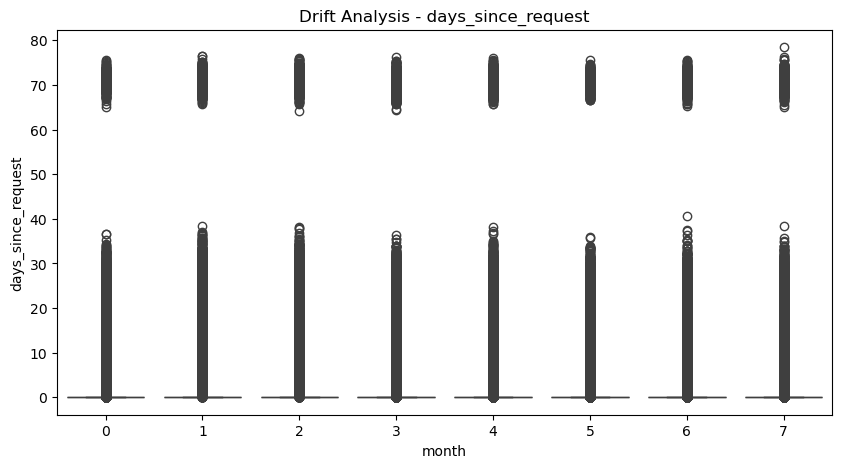

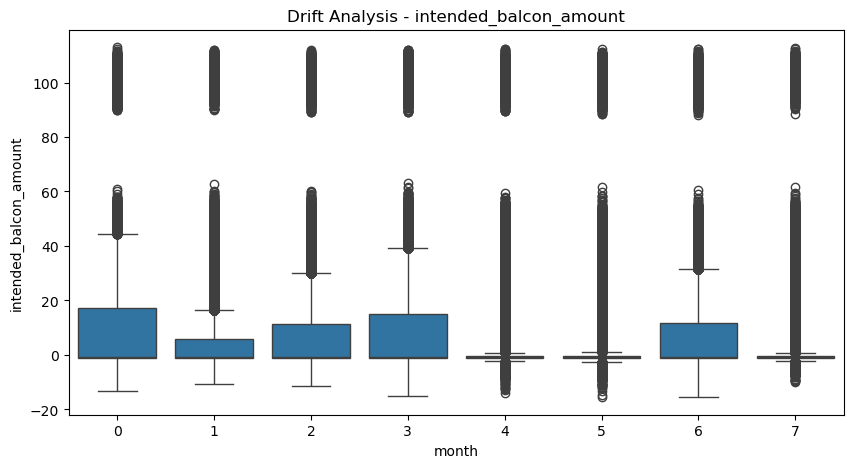

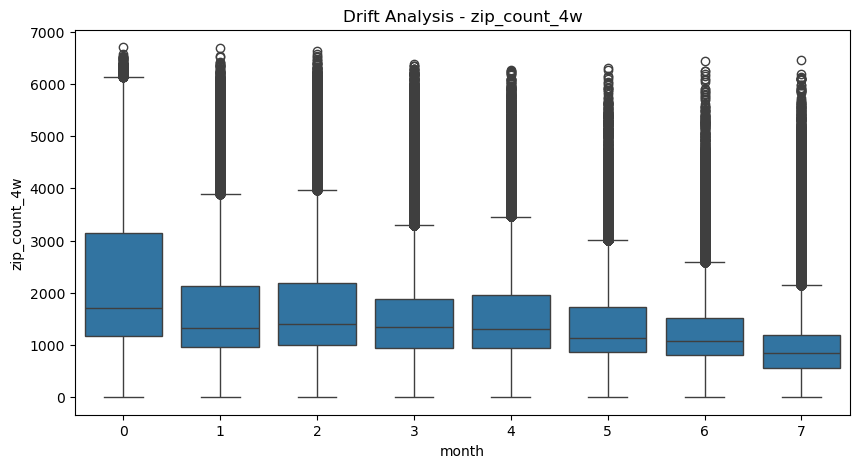

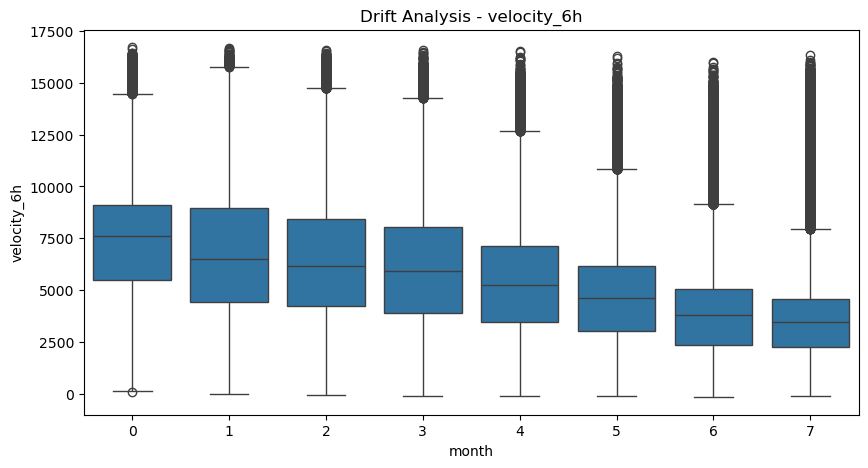

       fraud_bool    income  name_email_similarity  prev_address_months_count  \
month                                                                           
0        0.011326  0.545999               0.480271                  17.995500   
1        0.009387  0.520698               0.526254                  13.645886   
2        0.008746  0.496552               0.536123                  18.444623   
3        0.009222  0.563151               0.485859                  20.081637   
4        0.011371  0.580703               0.490350                  16.521697   

       current_address_months_count  customer_age  days_since_request  \
month                                                                   
0                         85.359333     33.566898            0.721744   
1                        100.431257     33.093637            1.346258   
2                         80.539418     33.664503            1.511642   
3                         79.237511     34.426711            0.9964

In [1]:
# ==========================================================
# DRIFT_ANALYSIS.PY
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("Base.csv")

# ==========================================================
# CHECK MONTH COLUMN
# ==========================================================
if "month" not in df.columns:
    raise ValueError("month column not found")

# ==========================================================
# FRAUD DRIFT
# ==========================================================
monthly_fraud = (
    df.groupby("month")["fraud_bool"]
    .mean()
)

print(monthly_fraud)

monthly_fraud.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Fraud Rate Drift")

plt.ylabel("Fraud Rate")

plt.show()

# ==========================================================
# FEATURE DISTRIBUTION DRIFT
# ==========================================================
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols[:10]:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        x="month",
        y=col,
        data=df
    )

    plt.title(f"Drift Analysis - {col}")

    plt.show()

# ==========================================================
# MONTHLY STATISTICS
# ==========================================================
monthly_stats = (
    df.groupby("month")[num_cols]
    .mean()
)

print(monthly_stats.head())

# ==========================================================
# PSI (OPTIONAL)
# Population Stability Index
# ==========================================================

def calculate_psi(expected, actual, bins=10):

    expected_percents = np.histogram(
        expected,
        bins=bins
    )[0] / len(expected)

    actual_percents = np.histogram(
        actual,
        bins=bins
    )[0] / len(actual)

    psi = np.sum(
        (expected_percents - actual_percents)
        * np.log(
            (expected_percents + 1e-6)
            / (actual_percents + 1e-6)
        )
    )

    return psi

print("\n--- PSI ANALYSIS ---")

base_month = df[df["month"] == 0]

for month in sorted(df["month"].unique())[1:]:

    current = df[df["month"] == month]

    for col in num_cols[:5]:

        psi = calculate_psi(
            base_month[col],
            current[col]
        )

        print(f"Month {month} | {col} | PSI={psi:.4f}")